In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix

In [10]:
data_df = pd.read_csv("Hc22hp_r.csv")
feature_cols = ["R2WORD_TOTAL", "R2WORD_DSCORE",  "R2VERBAL_TOTAL", "R2DIG_SCORE", "R2HRSNAME_SCORE",]
data_df = data_df[["HHID", "R2MMSE_SCORE"] + feature_cols].dropna().reset_index(drop=True)
data_df["BINARY_MMSE"] = (data_df["R2MMSE_SCORE"] < 24) * 1
data_df

,HHID,R2MMSE_SCORE,R2WORD_TOTAL,R2WORD_DSCORE,R2VERBAL_TOTAL,R2DIG_SCORE,R2HRSNAME_SCORE,BINARY_MMSE
0,10038,29.0,20.0,4.0,19.0,48.0,3.0,0
1,10059,25.0,12.0,4.0,12.0,22.0,3.0,0
2,10299,23.0,20.0,7.0,18.0,32.0,2.0,1
3,10325,29.0,24.0,9.0,21.0,30.0,3.0,0
4,10394,30.0,21.0,8.0,19.0,38.0,3.0,0
...,...,...,...,...,...,...,...,...
2942,920697,28.0,24.0,8.0,10.0,31.0,3.0,0
2943,920760,21.0,10.0,3.0,9.0,20.0,3.0,1
2944,923486,26.0,15.0,2.0,17.0,22.0,3.0,0
2945,923487,27.0,11.0,2.0,16.0,29.0,3.0,0


In [11]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

X = data_df[feature_cols].to_numpy()
y_bin = data_df["BINARY_MMSE"].to_numpy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=96)

auc_scores = []
all_true = []
all_pred = []
all_prob = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_bin), 1):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_bin[train_idx], y_bin[test_idx]

    # ---- SMOTE only on training fold ----
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)

    # ---- Classifier ----
    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=100,
        random_state=12,
        n_jobs=-1
    )

    clf.fit(X_res, y_res)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    auc_scores.append(auc)

    all_true.append(y_test)
    all_pred.append(y_pred)
    all_prob.append(y_prob)

# ---- Aggregate Results ----
all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)
all_prob = np.concatenate(all_prob)

tn, fp, fn, tp = confusion_matrix(all_true, all_pred).ravel()

# Format: [[TN, FP], [FN, TP]]  (binary: 0 = no decline, 1 = cognitive decline)
print(f"AUC: {np.mean(auc_scores):.4f} \u00b1 {np.std(auc_scores):.4f}")
print(f"[[{tn}, {fp}], [{fn}, {tp}]]")
# tn + fp == 100
# fn + tp == 100

print(f"True Pos Rate: {tp / (tp + fn) * 100:.2f}%")
print(f"True Neg Rate: {tn / (tn + fp) * 100:.2f}%")
print(f"False Pos Rate: {fp / (fp + tn) * 100:.2f}%")
print(f"False Neg Rate: {fn / (fn + tp) * 100:.2f}%")


AUC: 0.8556 ± 0.0133
[[2519, 125], [163, 140]]
True Pos Rate: 46.20%
True Neg Rate: 95.27%
False Pos Rate: 4.73%
False Neg Rate: 53.80%


Explained variance ratio: [0.56250056 0.1621926 ]
Total explained variance: 0.7246931612988041


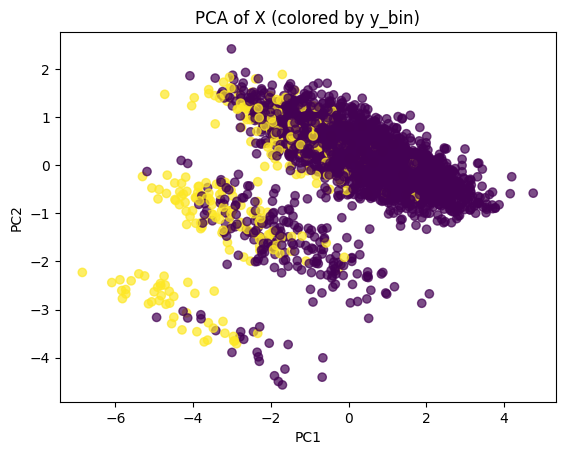

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2 components
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# Plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_bin, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of X (colored by y_bin)")
plt.show()

In [13]:
data_df = pd.read_csv("Hc22hp_r.csv")
data_df["R2TMA_TIME"] =  data_df["R2TMA_MIN"] * 60 + data_df["R2TMA_SEC"]
data_df["R2TMB_TIME"] =  data_df["R2TMB_MIN"] * 60 + data_df["R2TMB_SEC"]
feature_cols = ["R2HRSNAME_SCORE", "R2WORD_TOTAL", "R2VERBAL_TOTAL", "R2LC_SCORE", "R2BC_SCORE", "R2WORD_DSCORE", "R2BM_IMMSCORE", "R2LMB_IMMSCORE", "R2WLREC_TOTSCORE", "R2CP_SCORE", "R2DIG_SCORE", "R2CPDEL_SCORE", "R2BM_DELSCORE", "R2LMB_RECOSCORE", "R2NS_SCORE", "R2RV_SCORE", "R2TMA_SCORE", "R2TMA_TIME", "R2TMB_SCORE", "R2TMB_TIME"]
data_df = data_df[["HHID", "R2MMSE_SCORE"] + feature_cols].dropna().reset_index(drop=True)
data_df["BINARY_MMSE"] = (data_df["R2MMSE_SCORE"] < 24) * 1
data_df

/var/folders/34/b9jk4ztn4nq9jlq7ym1kx8q80000gn/T/ipykernel_67243/2728057475.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df["R2TMA_TIME"] =  data_df["R2TMA_MIN"] * 60 + data_df["R2TMA_SEC"]
/var/folders/34/b9jk4ztn4nq9jlq7ym1kx8q80000gn/T/ipykernel_67243/2728057475.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df["R2TMB_TIME"] =  data_df["R2TMB_MIN"] * 60 + data_df["R2TMB_SEC"]


,HHID,R2MMSE_SCORE,R2HRSNAME_SCORE,R2WORD_TOTAL,R2VERBAL_TOTAL,R2LC_SCORE,R2BC_SCORE,R2WORD_DSCORE,R2BM_IMMSCORE,R2LMB_IMMSCORE,...,R2CPDEL_SCORE,R2BM_DELSCORE,R2LMB_RECOSCORE,R2NS_SCORE,R2RV_SCORE,R2TMA_SCORE,R2TMA_TIME,R2TMB_SCORE,R2TMB_TIME,BINARY_MMSE
0,10038,29.0,3.0,20.0,19.0,17.0,35.0,4.0,8.0,11.0,...,4.0,0.0,12.0,584.0,15.0,42.0,42.0,67.0,67.0,0
1,10299,23.0,2.0,20.0,18.0,26.0,17.0,7.0,7.0,6.0,...,11.0,0.0,9.0,996.0,5.0,30.0,30.0,66.0,66.0,1
2,10325,29.0,3.0,24.0,21.0,20.0,35.0,9.0,8.0,13.0,...,7.0,8.0,14.0,519.0,14.0,26.0,26.0,106.0,106.0,0
3,10451,25.0,3.0,17.0,12.0,19.0,27.0,6.0,6.0,8.0,...,6.0,5.0,10.0,528.0,13.0,52.0,52.0,120.0,120.0,0
4,10482,27.0,3.0,17.0,11.0,16.0,29.0,6.0,7.0,6.0,...,9.0,7.0,7.0,529.0,11.0,42.0,42.0,70.0,70.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2345,920697,28.0,3.0,24.0,10.0,16.0,23.0,8.0,6.0,9.0,...,6.0,5.0,12.0,518.0,3.0,83.0,83.0,132.0,132.0,0
2346,920760,21.0,3.0,10.0,9.0,11.0,19.0,3.0,6.0,2.0,...,4.0,0.0,11.0,996.0,4.0,93.0,93.0,262.0,262.0,1
2347,923486,26.0,3.0,15.0,17.0,17.0,17.0,2.0,5.0,13.0,...,4.0,5.0,15.0,501.0,4.0,50.0,50.0,78.0,78.0,0
2348,923487,27.0,3.0,11.0,16.0,13.0,11.0,2.0,4.0,7.0,...,9.0,2.0,13.0,462.0,15.0,39.0,39.0,70.0,70.0,0


In [14]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix

results = []

y_full = data_df["R2MMSE_SCORE"].values
y_binary = (y_full < 24).astype(int)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for col in feature_cols:
    
    X_full = data_df[[col]].values
    
    rmse_scores = []
    acc_scores = []
    tpr_scores = []
    
    for train_idx, test_idx in kf.split(X_full, y_binary):
        
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_full[train_idx], y_full[test_idx]
        y_test_bin = y_binary[test_idx]
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        # ----- Regression -----
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmse_scores.append(rmse)
        
        # ----- Binary -----
        y_pred_bin = (y_pred < 24).astype(int)
        
        acc = accuracy_score(y_test_bin, y_pred_bin)
        acc_scores.append(acc)
        
        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(
            y_test_bin, y_pred_bin, labels=[0,1]
        ).ravel()
        
        # True Positive Rate (Sensitivity)
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        tpr_scores.append(tpr)
    
    results.append({
        "feature": col,
        "rmse_mean": np.mean(rmse_scores),
        "rmse_std": np.std(rmse_scores),
        "binary_acc_mean": np.mean(acc_scores),
        "binary_acc_std": np.std(acc_scores),
        "tpr_mean": np.mean(tpr_scores),
        "tpr_std": np.std(tpr_scores)
    })

results_df = pd.DataFrame(results).sort_values("rmse_mean")

print(results_df)

             feature  rmse_mean  rmse_std  binary_acc_mean  binary_acc_std  \
10       R2DIG_SCORE   2.025569  0.113068         0.950638        0.000851   
15        R2RV_SCORE   2.048981  0.112869         0.948936        0.002331   
19        R2TMB_TIME   2.053566  0.145329         0.950638        0.000851   
18       R2TMB_SCORE   2.053566  0.145329         0.950638        0.000851   
7     R2LMB_IMMSCORE   2.060622  0.132084         0.950638        0.000851   
11     R2CPDEL_SCORE   2.076589  0.135168         0.950638        0.000851   
1       R2WORD_TOTAL   2.077075  0.095678         0.950638        0.000851   
5      R2WORD_DSCORE   2.093238  0.122924         0.950638        0.000851   
4         R2BC_SCORE   2.094095  0.123631         0.950638        0.000851   
17        R2TMA_TIME   2.099132  0.108760         0.948085        0.002170   
16       R2TMA_SCORE   2.099132  0.108760         0.948085        0.002170   
9         R2CP_SCORE   2.121215  0.115930         0.950638      